# Cleaning - missing and duplicate data

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('ggplot')
import pandas as pd
import numpy as np

# Display all cell outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from IPython import get_ipython
ipython = get_ipython()

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# Set max rows and columns displayed in jupyter
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

# autoreload extension
if 'autoreload' not in ipython.extension_manager.loaded:
    %load_ext autoreload

%autoreload 2

#want to filter the seaborn warnings
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")
warnings.filterwarnings("ignore", category=FutureWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate a t-shirt order
have a name, a t-shirt size, a t-shirt color and a weight(in pounds)<br>
Uses the <a href="https://pypi.org/project/names/">names </a> module to generate random names

In [42]:
import utils as ut
df = ut.generate_tshirt_order()
df

,weight,t_shirt_size,t_shirt_color,name
0,110.580941,small,orange,Elsie Bosarge
1,104.298628,small,red,Gladys Robinson
2,118.498089,small,black,Christina Reiner
3,89.022939,small,orange,Gail Jackson
4,113.212132,small,green,Dixie Benson
...,...,...,...,...
295,132.074753,large,green,Lizzie Lechner
296,187.922335,large,green,Carl Lawton
297,148.394469,large,orange,Anthony Sanders
298,205.896573,large,orange,Jamie Parker


### Make some duplicates

In [43]:
# make some duplicates just to show how to handle duplicates (delete them)
#lets find the oldest male and female
def fun1(df,numb=5):
    #generates numb rows from df
    return (df.iloc[0:numb,:])


#generates numb rows from each group to be used as duplicates
df_dups=df.groupby('t_shirt_size').apply(fun1)
df_dups

C:\Users\ereno\AppData\Local\Temp\ipykernel_22776\2802302565.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dups=df.groupby('t_shirt_size').apply(fun1)


weight t_shirt_size t_shirt_color              name
t_shirt_size                                                             
large        200  165.073121        large         black      Alan Morales
             201  151.675235        large         green   Ricardo Arimoto
             202  155.633956        large         black  Joseph Cardimino
             203  211.451342        large        orange  Gabriela Cargill
             204  124.147998        large         black       Gena Bruder
medium       100  146.275740       medium           red      Chad Navarro
             101  125.332669       medium         black    Brent Lundberg
             102  135.324501       medium         black        Kim Aigner
             103  143.156728       medium          blue      Ross Knudson
             104  122.844924       medium         black       James Perez
small        0    110.580941        small        orange     Elsie Bosarge
             1    104.298628        small           red   Gladys Robinson
             2    118.498089        small         black  Christina Reiner
             3     89.022939        small        orange      Gail Jackson
             4    113.212132        small         green      Dixie Benson

### Append to original dataframe

In [44]:
df=pd.concat([df,df_dups],ignore_index=True)
#the old, soon to be deprecated way
# df=df.append(df_dups, ignore_index=True)
len(df)

315

In [45]:
df.duplicated().sum()

np.int64(15)

In [46]:
df[df.duplicated()].sort_values('name')

,weight,t_shirt_size,t_shirt_color,name
300,165.073121,large,black,Alan Morales
306,125.332669,medium,black,Brent Lundberg
305,146.275740,medium,red,Chad Navarro
312,118.498089,small,black,Christina Reiner
314,113.212132,small,green,Dixie Benson
310,110.580941,small,orange,Elsie Bosarge
303,211.451342,large,orange,Gabriela Cargill
313,89.022939,small,orange,Gail Jackson
304,124.147998,large,black,Gena Bruder
311,104.298628,small,red,Gladys Robinson


### randomly select 20% of rows for t_shirt_size ommision

In [47]:
import random
res = random.sample(range(0, len(df)), int(0.2 * len(df)))
print(f'Number of rows to have "t_shirt_size" set to np.Nan is {len(res)}' )

Number of rows to have "t_shirt_size" set to np.Nan is 63


In [48]:
#first, save orig size
df['t_shirt_size_orig'] = df['t_shirt_size']  #all rows
# df['t_shirt_size_orig'] = df.loc[res,'t_shirt_size'] #just the rows to be set to np.NaN

#then lose orig size
df.loc[res,'t_shirt_size']=np.nan
df

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
0,110.580941,small,orange,Elsie Bosarge,small
1,104.298628,small,red,Gladys Robinson,small
2,118.498089,small,black,Christina Reiner,small
3,89.022939,small,orange,Gail Jackson,small
4,113.212132,small,green,Dixie Benson,small
...,...,...,...,...,...
310,110.580941,small,orange,Elsie Bosarge,small
311,104.298628,NaN,red,Gladys Robinson,small
312,118.498089,small,black,Christina Reiner,small
313,89.022939,NaN,orange,Gail Jackson,small


In [49]:
#how many total
#df.isna().sum().sum()

#how many are null?
df.t_shirt_size.isna().sum()

np.int64(63)

In [50]:
#show the missing data
df[df.t_shirt_size.isna()].head()

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
7,122.447078,NaN,orange,Anthony Briggs,small
8,119.772491,NaN,blue,Edward Wrede,small
10,127.215041,NaN,green,Stephen Moreno,small
13,95.609882,NaN,black,Charles Jones,small
15,78.450495,NaN,red,Ralph Lawson,small


### Lets take a look at the distribution

#### kind ='hist', hist will bin the number of weights and display them, hue will determine which color group they belong to

In [51]:
sns.displot(data=df, x="weight",  hue="t_shirt_size", kind='hist', fill=True);

#### kind ='kde', kde is a kernel density estimater, essentially calculates a gaussian distribution around each point, and then adds these distributions, and then divides by the number of points to get the smooth curves you see that have an area of 1.  I'm showing it because its easier to see the distributions

In [52]:
sns.displot(data=df, x="weight",  hue="t_shirt_size", kind='kde', fill=True);

### Find them first

In [53]:
df.duplicated(keep=False).sum()

np.int64(22)

### Visually Verify 

In [54]:
df[df.duplicated(keep=False)].sort_values(by='name')

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
300,165.073121,large,black,Alan Morales,large
200,165.073121,large,black,Alan Morales,large
101,125.332669,medium,black,Brent Lundberg,medium
306,125.332669,medium,black,Brent Lundberg,medium
100,146.275740,medium,red,Chad Navarro,medium
305,146.275740,medium,red,Chad Navarro,medium
312,118.498089,small,black,Christina Reiner,small
2,118.498089,small,black,Christina Reiner,small
310,110.580941,small,orange,Elsie Bosarge,small
0,110.580941,small,orange,Elsie Bosarge,small


### Now drop the regular duplicates that are not missing data

In [55]:
df.duplicated??


Signature:
df.duplicated(
    subset: 'Hashable | Sequence[Hashable] | None' = None,
    keep: 'DropKeep' = 'first',
) -> 'Series'
Source:   
    def duplicated(
        self,
        subset: Hashable | Sequence[Hashable] | None = None,
        keep: DropKeep = "first",
    ) -> Series:
        """
        Return boolean Series denoting duplicate rows.

        Considering certain columns is optional.

        Parameters
        ----------
        subset : column label or sequence of labels, optional
            Only consider certain columns for identifying duplicates, by
            default use all of the columns.
        keep : {'first', 'last', False}, default 'first'
            Determines which duplicates (if any) to mark.

            - ``first`` : Mark duplicates as ``True`` except for the first occurrence.
            - ``last`` : Mark duplicates as ``True`` except for the last occurrence.
            - False : Mark all duplicates as ``True``.

        Returns
        -------
 

In [56]:
df.drop( df[df.duplicated(keep='first')].index, inplace=True)

In [57]:
len(df)

304

## What if one of the duplicated rows is missing the t-shirt size?  Then duplicated() will not find it.  Maybe we should check for duplicates in the 'name' column instead

start here 1/29/25

In [58]:
df.name.duplicated(keep=False).sum()

np.int64(8)

### Verify that they are duplicates first

In [59]:
df[df.name.duplicated(keep=False)].sort_values(by='name')

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
4,113.212132,small,green,Dixie Benson,small
314,113.212132,NaN,green,Dixie Benson,small
3,89.022939,small,orange,Gail Jackson,small
313,89.022939,NaN,orange,Gail Jackson,small
1,104.298628,small,red,Gladys Robinson,small
311,104.298628,NaN,red,Gladys Robinson,small
202,155.633956,large,black,Joseph Cardimino,large
302,155.633956,NaN,black,Joseph Cardimino,large


### We want to delete the one that has a np.nan for t_shirt_size.

In [60]:
# to see the indexis that will be dropped
df[df.name.duplicated(keep=False) & (df.t_shirt_size.isna())].index

Index([302, 311, 313, 314], dtype='int64')

In [61]:
df.drop( df[df.name.duplicated(keep=False) & (df.t_shirt_size.isna())].index, inplace=True)

## Duplicates are gone, now how to impute the missing fields

In [62]:
len(df[(df['t_shirt_size'].isnull())])

59

In [63]:
# how many match
def printstats(df):
    numbmatches=(df['t_shirt_size_orig']==df['t_shirt_size']).sum()
    print(f'{numbmatches} tshirt sizes are correct out of {len(df)} total')

### One way is to use SimpleImputer and assign the median value to all the missing values


In [64]:
df_med=df.copy()
df_med

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
0,110.580941,small,orange,Elsie Bosarge,small
1,104.298628,small,red,Gladys Robinson,small
2,118.498089,small,black,Christina Reiner,small
3,89.022939,small,orange,Gail Jackson,small
4,113.212132,small,green,Dixie Benson,small
...,...,...,...,...,...
295,132.074753,large,green,Lizzie Lechner,large
296,187.922335,large,green,Carl Lawton,large
297,148.394469,NaN,orange,Anthony Sanders,large
298,205.896573,large,orange,Jamie Parker,large


In [65]:
# df[df.t_shirt_size.isnull()]

In [66]:
df.t_shirt_size.value_counts(dropna=False)

t_shirt_size
medium    81
small     80
large     80
NaN       59
Name: count, dtype: int64

In [67]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent',add_indicator=True)  #works with strings
imp = imp.fit(df_med[['t_shirt_size']])   #here is where it determines what the most frequent is
df_med['t_shirt_size']=imp.transform(df_med[['t_shirt_size']])[:,0] #here is where the transform is applied 
# imp.transform(df_med[['t_shirt_size']])[:,0]

In [68]:
printstats(df_med)

260 tshirt sizes are correct out of 300 total


### Another way is to find the mean weight for each t-shirt size, and then assign missing value t-shirt size based on weight
For each NaN, assign t-shirt size to closest mean

#### First calculate average weight for each t-shirt size

In [69]:
df_better = df.copy()

In [70]:
avgs = df_better.groupby('t_shirt_size').weight.mean()
avgs

t_shirt_size
large     175.978335
medium    138.489592
small     102.278039
Name: weight, dtype: float64

In [71]:
#how many in each group
df_better.groupby('t_shirt_size').count()

,weight,t_shirt_color,name,t_shirt_size_orig
t_shirt_size,,,,
large,80,80,80,80
medium,81,81,81,81
small,80,80,80,80


#### Impute the value, replace any NaNs, and add a 1 in a column to indicate that this value was imputed 
<mark>The indicater column will inform a ML algorithm that this value was imputed

In [72]:
#map works on a column apply works on a row, which means we have access tothe entire row
#can also return more than 1 value so that we can have an indicator value

def func(row):
    if row.t_shirt_size is np.nan:
        #which avgs.weight is this weight closest to?
        
        #get a list of differences between this weight and average weights
        lst_vals = [abs(row.weight-val) for val in avgs]

        #get the index of the minimum value
        min_val = min(lst_vals)
        min_index=lst_vals.index(min_val)

        #return t_shirt_size corresponding to this index
        return pd.Series([avgs.index[min_index],True],index=['t_shirt_size','t_shirt_size_indicator'])
    #its not missing, return what's there
    return pd.Series([row.t_shirt_size,False],index=['t_shirt_size','t_shirt_size_indicator'])
# df_better['t_shirt_size_indicator']=False
df_better[['t_shirt_size','t_shirt_size_indicator']]=df_better.apply(func, axis=1)

In [73]:
df.head()

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig
0,110.580941,small,orange,Elsie Bosarge,small
1,104.298628,small,red,Gladys Robinson,small
2,118.498089,small,black,Christina Reiner,small
3,89.022939,small,orange,Gail Jackson,small
4,113.212132,small,green,Dixie Benson,small


In [74]:
printstats(df_better)

287 tshirt sizes are correct out of 300 total


In [75]:
#see which ones it got wrong, look at the distributions in above plots
#it got them wrong because the weights were outliers
dfb=df_better[(df_better['t_shirt_size'] != df_better['t_shirt_size_orig'])]

sns.displot(data=dfb, x="weight",  hue="t_shirt_size", kind='hist', fill=True);

In [76]:
# Plot the distribution
sns.displot(data=dfb, x="weight", hue="t_shirt_size", kind='hist', fill=True)

# Add vertical lines for the average weights
for size, avg_weight in avgs.items():
    plt.axvline(avg_weight, linestyle='--', label=f'Average {size}', color='red')

# Add legend
plt.legend();

In [77]:
# Plot the distribution
sns.displot(data=dfb, x="weight", hue="t_shirt_size", kind='hist', fill=True)

# Add vertical lines for the average weights
for size, avg_weight in avgs.items():
    plt.axvline(avg_weight, linestyle='--', label=f'Average {size}', color='red')

# Add vertical lines for the range of weights for 'small' t-shirt size using t_shirt_size_orig
small_weights = df[df['t_shirt_size_orig'] == 'small']['weight']
plt.axvline(small_weights.min(), linestyle='-', color='blue', label='Min weight (small)')
plt.axvline(small_weights.max(), linestyle='-', color='green', label='Max weight (small)')

# Add legend
plt.legend();

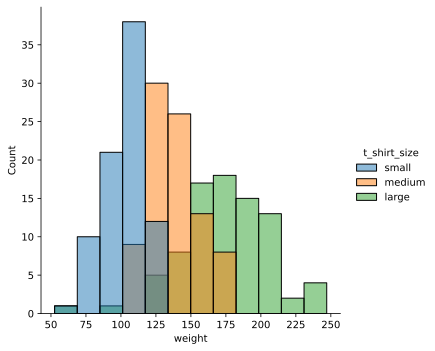

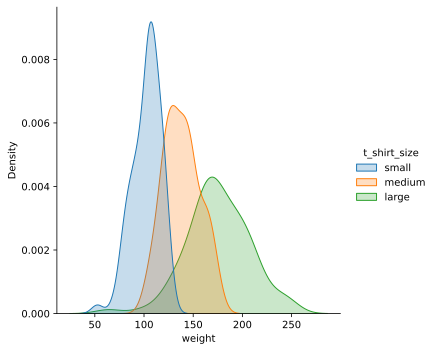

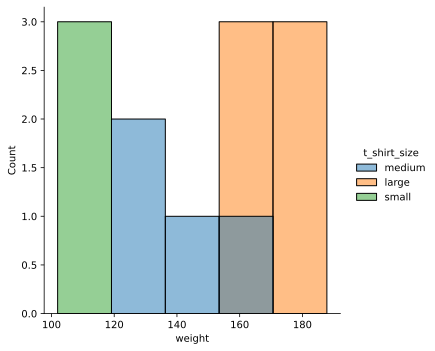

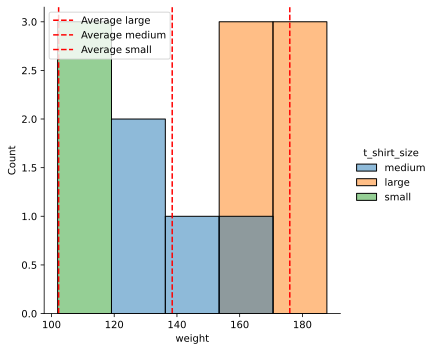

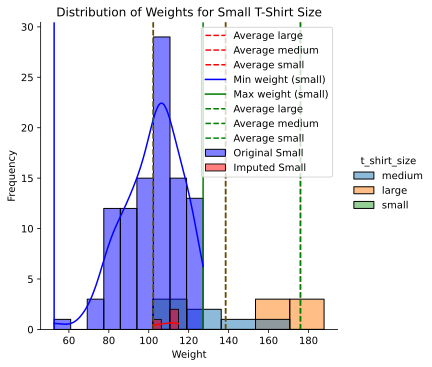

In [78]:
# Plot the distribution of weights for the "small" t-shirt size
sns.histplot(data=df[df['t_shirt_size_orig'] == 'small'], x='weight', color='blue', label='Original Small', kde=True)

# Plot the weights of the incorrectly imputed t-shirt sizes
sns.histplot(data=dfb[dfb['t_shirt_size'] == 'small'], x='weight', color='red', label='Imputed Small', kde=True)

# Add vertical lines for the average weights
for size, avg_weight in avgs.items():
    plt.axvline(avg_weight, linestyle='--', label=f'Average {size}', color='green')

# Add legend
plt.legend()
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Weights for Small T-Shirt Size')
plt.show();

In [79]:
incorrect_imputations = dfb[dfb['t_shirt_size'] != dfb['t_shirt_size_orig']]
incorrect_imputations

,weight,t_shirt_size,t_shirt_color,name,t_shirt_size_orig,t_shirt_size_indicator
7,122.447078,medium,orange,Anthony Briggs,small,True
10,127.215041,medium,green,Stephen Moreno,small,True
106,158.963452,large,orange,Barbara Balzer,medium,True
117,181.396054,large,orange,Evelyn Buckley,medium,True
125,110.886025,small,blue,Pamela Williams,medium,True
127,170.064506,large,orange,Kenneth Mertens,medium,True
141,101.959821,small,red,Pamela Farina,medium,True
161,187.803442,large,blue,Dawn Young,medium,True
191,167.039166,large,blue,Daniel Santos,medium,True
192,172.718971,large,black,Mary Graves,medium,True


# Generate Slide for the lecture

In [80]:
def func(df, numb=5):
    return (df.iloc[0:numb,:])
    
df.groupby('t_shirt_size', dropna=False).apply(func,numb=3)

C:\Users\ereno\AppData\Local\Temp\ipykernel_22776\4283629973.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('t_shirt_size', dropna=False).apply(func,numb=3)


weight t_shirt_size t_shirt_color              name  \
t_shirt_size                                                                
large        200  165.073121        large         black      Alan Morales   
             201  151.675235        large         green   Ricardo Arimoto   
             202  155.633956        large         black  Joseph Cardimino   
medium       100  146.275740       medium           red      Chad Navarro   
             101  125.332669       medium         black    Brent Lundberg   
             102  135.324501       medium         black        Kim Aigner   
small        0    110.580941        small        orange     Elsie Bosarge   
             1    104.298628        small           red   Gladys Robinson   
             2    118.498089        small         black  Christina Reiner   
NaN          7    122.447078          NaN        orange    Anthony Briggs   
             8    119.772491          NaN          blue      Edward Wrede   
             10   127.215041          NaN         green    Stephen Moreno   

                 t_shirt_size_orig  
t_shirt_size                        
large        200             large  
             201             large  
             202             large  
medium       100            medium  
             101            medium  
             102            medium  
small        0               small  
             1               small  
             2               small  
NaN          7               small  
             8               small  
             10              small